In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
fund = pd.read_csv("../Data/raw/01_fund_master.csv")

nav = pd.read_csv("../Data/raw/02_nav_history.csv")

performance = pd.read_csv("../Data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../Data/raw/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [4]:
nav = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [5]:
nav = nav.sort_values(["scheme_name","date"])

nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

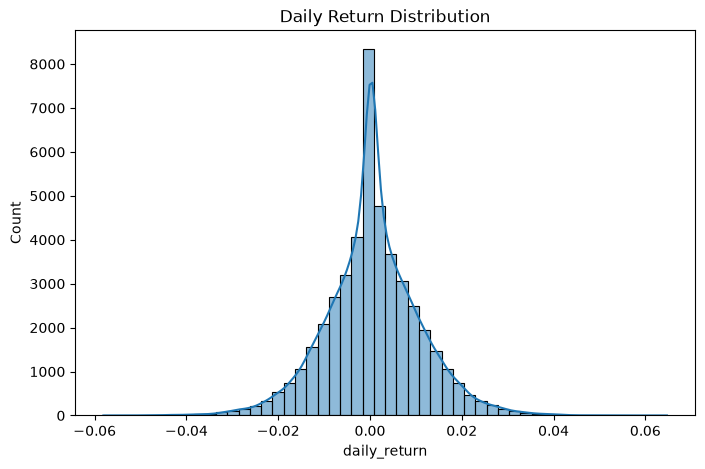

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [7]:
def CAGR(start,end,years):
    return (end/start)**(1/years)-1

In [8]:
result=[]

for fund_name,data in nav.groupby("scheme_name"):

    data=data.sort_values("date")

    start=data["nav"].iloc[0]

    end=data["nav"].iloc[-1]

    years=(data["date"].max()-data["date"].min()).days/365

    cagr=CAGR(start,end,years)

    result.append([fund_name,cagr])

cagr_table=pd.DataFrame(
    result,
    columns=["Fund","CAGR"]
)

cagr_table

,Fund,CAGR
0,ABSL Frontline Equity Fund - Regular - Growth,0.235205
1,ABSL Liquid Fund - Regular - Growth,0.065044
2,ABSL Small Cap Fund - Regular - Growth,0.079331
3,Axis Bluechip Fund - Direct - Growth,0.078919
4,Axis Bluechip Fund - Regular - Growth,0.063635
5,Axis Midcap Fund - Regular - Growth,0.281926
6,Axis Small Cap Fund - Regular - Growth,0.015205
7,DSP Midcap Fund - Regular - Growth,0.295581
8,DSP Small Cap Fund - Regular - Growth,0.322621
9,DSP Top 100 Equity Fund - Regular - Growth,0.133835


In [9]:
rf=0.065

In [10]:
sharpe=[]

for fund_name,data in nav.groupby("scheme_name"):

    r=data["daily_return"].dropna()

    ratio=((r.mean()-rf/252)/r.std())*np.sqrt(252)

    sharpe.append([fund_name,ratio])

sharpe=pd.DataFrame(
    sharpe,
    columns=["Fund","Sharpe"]
)

sharpe.sort_values(
    "Sharpe",
    ascending=False
)

,Fund,Sharpe
25,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
22,Kotak Flexicap Fund - Regular - Growth,1.306744
26,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
33,SBI Bluechip Fund - Regular Plan - Growth,1.208267
18,ICICI Pru Midcap Fund - Regular - Growth,1.180101
7,DSP Midcap Fund - Regular - Growth,1.132122
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
30,Nippon India Large Cap Fund - Regular - Growth,1.081659
0,ABSL Frontline Equity Fund - Regular - Growth,1.027213
15,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


In [11]:
sortino=[]

for fund_name,data in nav.groupby("scheme_name"):

    r=data["daily_return"].dropna()

    downside=r[r<0]

    ratio=((r.mean()-rf/252)/downside.std())*np.sqrt(252)

    sortino.append([fund_name,ratio])

sortino=pd.DataFrame(
    sortino,
    columns=["Fund","Sortino"]
)

In [12]:
merged=nav.merge(
    benchmark,
    on="date"
)

In [15]:
print(merged.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return', 'index_name', 'close_value']


In [16]:
benchmark = pd.read_csv("../Data/raw/10_benchmark_indices.csv")

print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [17]:
print(benchmark.head())
print(benchmark.columns.tolist())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
['date', 'index_name', 'close_value']


In [19]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

In [20]:
nifty100 = benchmark[
    benchmark["index_name"].str.contains("Nifty 100", case=False, na=False)
].copy()

In [21]:
merged["date"] = pd.to_datetime(merged["date"])

merged = merged.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [22]:
print(merged.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return', 'index_name', 'close_value', 'benchmark_return']


In [23]:
from scipy.stats import linregress

alpha_beta = []

for fund_name, data in merged.groupby("scheme_name"):

    data = data.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(data) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        data["benchmark_return"],
        data["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        fund_name,
        alpha,
        beta
    ])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=["Fund", "Alpha", "Beta"]
)

print(alpha_beta)

Empty DataFrame
Columns: [Fund, Alpha, Beta]
Index: []


In [35]:
alpha_beta.to_csv(
    "../charts/alpha_beta.csv",
    index=False
)

In [26]:
drawdown=[]

for fund_name,data in nav.groupby("scheme_name"):

    running_max=data["nav"].cummax()

    dd=data["nav"]/running_max-1

    drawdown.append(
        [fund_name,dd.min()]
    )

drawdown=pd.DataFrame(
    drawdown,
    columns=[
        "Fund",
        "Max Drawdown"
    ]
)

In [27]:
score=cagr_table.merge(sharpe)

score=score.merge(alpha_beta)

score=score.merge(drawdown)

In [28]:
score["Return Rank"]=score["CAGR"].rank()

score["Sharpe Rank"]=score["Sharpe"].rank()

score["Alpha Rank"]=score["Alpha"].rank()

score["DD Rank"]=(-score["Max Drawdown"]).rank()

In [29]:
score["Score"]=(
0.30*score["Return Rank"]+
0.25*score["Sharpe Rank"]+
0.20*score["Alpha Rank"]+
0.25*score["DD Rank"]
)

In [36]:
score.to_csv(
    "../charts/fund_scorecard.csv",
    index=False
)

In [31]:
top5=score.nlargest(
5,
"Score"
)["Fund"]

C:\Users\V Venkata lakshmi\AppData\Local\Temp\ipykernel_18220\2058250473.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


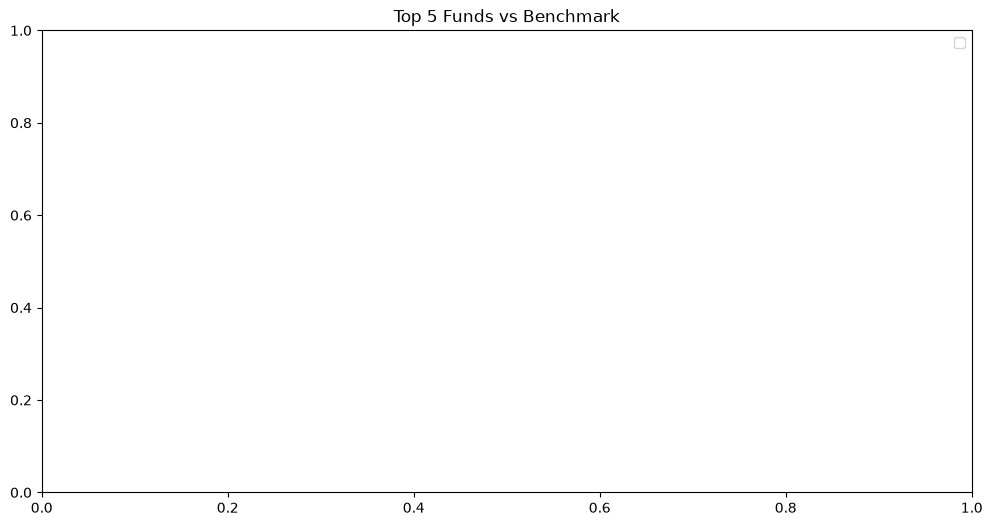

In [32]:
plt.figure(figsize=(12,6))

for fund_name in top5:

    data=nav[
        nav["scheme_name"]==fund_name
    ]

    plt.plot(
        data["date"],
        data["nav"],
        label=fund_name
    )

plt.legend()

plt.title(
"Top 5 Funds vs Benchmark"
)

plt.savefig(
"../charts/benchmark_comparison.png"
)

plt.show()

In [33]:
merged["tracking_error"]=(
merged["daily_return"]-
merged["benchmark_return"]
)

tracking=merged.groupby(
"scheme_name"
)["tracking_error"].std()*np.sqrt(252)

tracking

Series([], Name: tracking_error, dtype: float64)